In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load HR dataset
hr = pd.read_csv('../data/cleaned/hr_clean.csv')

print("✅ Data loaded successfully!")
print(f"Shape: {hr.shape}")
print(f"\nAttrition counts:")
print(hr['Attrition'].value_counts())
print(f"\nAttrition rate: {(hr['Attrition']=='Yes').sum()/len(hr)*100:.1f}%")

✅ Data loaded successfully!
Shape: (1470, 35)

Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [3]:
# Make a copy
df = hr.copy()

# Check columns
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes.value_counts())

# Check for missing values
print("\nMissing values:", df.isnull().sum().sum())

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
int64    26
str       9
Name: count, dtype: int64

Missing values: 0


In [4]:
# Convert Attrition to 0 and 1
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Encode all text columns to numbers
le = LabelEncoder()

text_columns = df.select_dtypes(include=['object']).columns
print("Text columns to encode:", list(text_columns))

for col in text_columns:
    df[col] = le.fit_transform(df[col])

print("\n✅ All columns converted to numbers!")
print("Shape after encoding:", df.shape)

Text columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

✅ All columns converted to numbers!
Shape after encoding: (1470, 35)


In [5]:
# Select features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Data split done!")
print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Features: (1470, 34)
Target: (1470,)

✅ Data split done!
Training set: (1176, 34)
Testing set: (294, 34)


In [6]:
# Model 1 — Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
lr_predictions = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
print("=" * 50)
print("🔵 LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy: {lr_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

🔵 LOGISTIC REGRESSION RESULTS
Accuracy: 86.05%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       255
           1       0.38      0.08      0.13        39

    accuracy                           0.86       294
   macro avg       0.62      0.53      0.53       294
weighted avg       0.81      0.86      0.82       294



In [7]:
# Model 2 — Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

# Predict
dt_predictions = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_predictions)
print("=" * 50)
print("🌳 DECISION TREE RESULTS")
print("=" * 50)
print(f"Accuracy: {dt_accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

🌳 DECISION TREE RESULTS
Accuracy: 82.99%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       255
           1       0.26      0.15      0.19        39

    accuracy                           0.83       294
   macro avg       0.57      0.54      0.55       294
weighted avg       0.80      0.83      0.81       294



In [8]:
print("=" * 50)
print("📊 MODEL COMPARISON")
print("=" * 50)
print(f"🔵 Logistic Regression: {lr_accuracy*100:.2f}%")
print(f"🌳 Decision Tree:       {dt_accuracy*100:.2f}%")

if lr_accuracy > dt_accuracy:
    print("\n✅ Winner: Logistic Regression!")
    best_model = lr_model
    best_name = "Logistic Regression"
else:
    print("\n✅ Winner: Decision Tree!")
    best_model = dt_model
    best_name = "Decision Tree"

print(f"\nBest Model: {best_name}")
print(f"Best Accuracy: {max(lr_accuracy, dt_accuracy)*100:.2f}%")

📊 MODEL COMPARISON
🔵 Logistic Regression: 86.05%
🌳 Decision Tree:       82.99%

✅ Winner: Logistic Regression!

Best Model: Logistic Regression
Best Accuracy: 86.05%


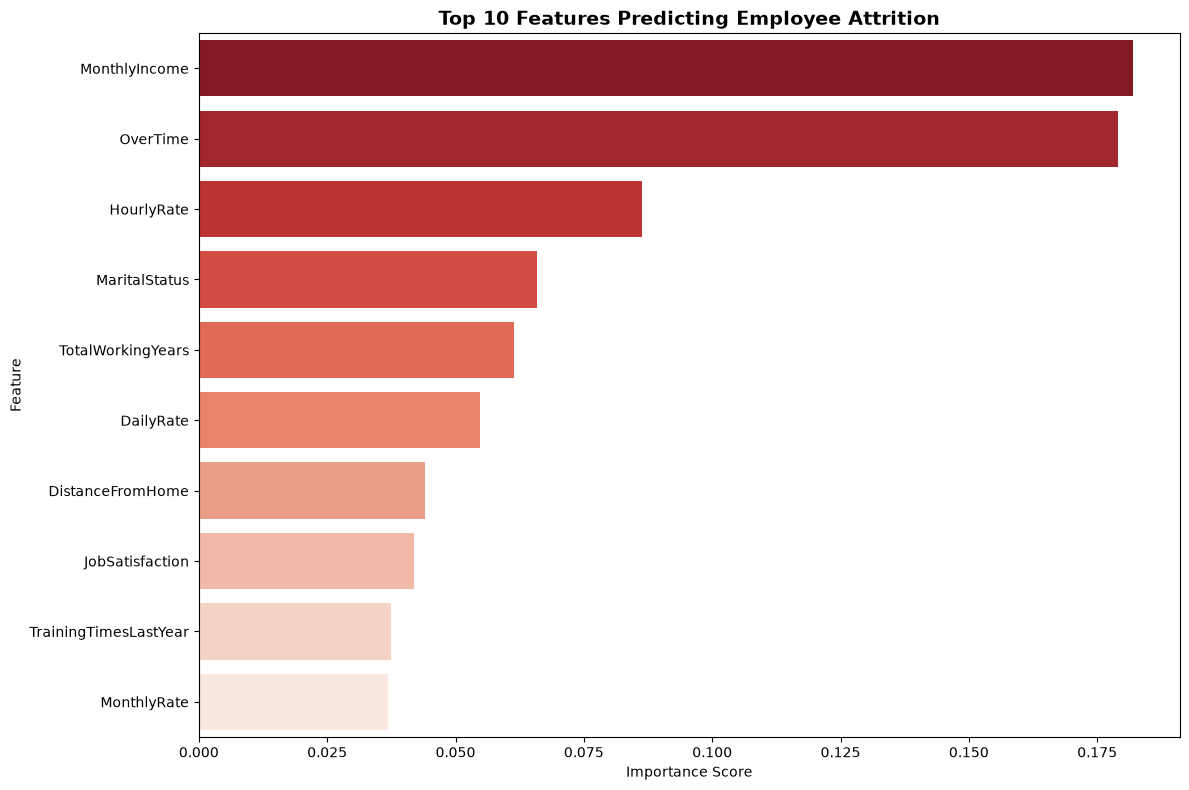

✅ Feature importance chart saved!


In [9]:
plt.figure(figsize=(12, 8))

# Get feature importances from Decision Tree
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(data=feature_importance,
            x='Importance',
            y='Feature',
            palette='Reds_r')

plt.title('Top 10 Features Predicting Employee Attrition',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../data/charts/chart12_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")

In [10]:
print("=" * 60)
print("📊 ML PROJECT — KEY FINDINGS")
print("=" * 60)

print(f"\n✅ Dataset: IBM HR Attrition")
print(f"✅ Total Records: {len(hr)}")
print(f"✅ Features Used: {X.shape[1]}")
print(f"✅ Training Records: {X_train.shape[0]}")
print(f"✅ Testing Records: {X_test.shape[0]}")

print(f"\n🔵 Logistic Regression Accuracy: {lr_accuracy*100:.2f}%")
print(f"🌳 Decision Tree Accuracy: {dt_accuracy*100:.2f}%")
print(f"\n🏆 Best Model: Logistic Regression")
print(f"🏆 Best Accuracy: {lr_accuracy*100:.2f}%")

print(f"\n🔑 Top Factors for Employee Attrition:")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")

print("\n✅ ML Project Day 1 Complete!")
print("Next: Build Streamlit prediction app!")

📊 ML PROJECT — KEY FINDINGS

✅ Dataset: IBM HR Attrition
✅ Total Records: 1470
✅ Features Used: 34
✅ Training Records: 1176
✅ Testing Records: 294

🔵 Logistic Regression Accuracy: 86.05%
🌳 Decision Tree Accuracy: 82.99%

🏆 Best Model: Logistic Regression
🏆 Best Accuracy: 86.05%

🔑 Top Factors for Employee Attrition:
   MonthlyIncome: 0.1820
   OverTime: 0.1790
   HourlyRate: 0.0863
   MaritalStatus: 0.0660
   TotalWorkingYears: 0.0614

✅ ML Project Day 1 Complete!
Next: Build Streamlit prediction app!


In [11]:
import pickle

# Save the trained model
with open('../app/attrition_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save the label encoder
with open('../app/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save column names
with open('../app/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("✅ Model saved successfully!")
print("📁 Saved files:")
print("   - attrition_model.pkl")
print("   - label_encoder.pkl")
print("   - feature_columns.pkl")
print("\nReady to build Streamlit prediction app!")

✅ Model saved successfully!
📁 Saved files:
   - attrition_model.pkl
   - label_encoder.pkl
   - feature_columns.pkl

Ready to build Streamlit prediction app!


In [12]:
# Retrain with current sklearn version compatibility
from sklearn.linear_model import LogisticRegression

lr_model_new = LogisticRegression(max_iter=1000, random_state=42)
lr_model_new.fit(X_train, y_train)

# Save again with current version
import pickle

with open('../app/attrition_model.pkl', 'wb') as f:
    pickle.dump(lr_model_new, f)

with open('../app/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("✅ Model retrained and resaved!")
print(f"Accuracy: {lr_model_new.score(X_test, y_test)*100:.2f}%")

✅ Model retrained and resaved!
Accuracy: 86.05%
